# **CS 418 | Final Project Red Wine Quality Analysis**
## Predicting Red Wine Quality:
Physicochemical Approach using Machine Learning


---
## Team Information
### - **Team Number:** #15
### - **Team Members:**

| Name | NetID | UIN |
|------|-------|-----|
| Han Dang | ldang7 | 674712020 |
| Brian Ta | tta48 | 652177448 |
| Mahsa Alishiri | malish5 | 655044112 |

---
## Instructions for Running Code
####(more information in README file)
1. Open the project notebook in **Google Colab**
2. Click the **"Run all"** button on the top toolbar
3. Select **"Choose Files"** button on the left side of the Upload cell (waiting for input data)
4. From your local computer, upload the following **CSV file**:
   - `winequality-red.csv`
5. After uploading, all remaining cells should execute properly.


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload dataset: 'winequality-red.csv'
from google.colab import files
uploaded = files.upload()

Saving winequality-red.csv to winequality-red (1).csv


In [40]:
sns.set_theme(font="Serif")

# Data Cleaning & Processing (Brian)

In [41]:
# 1. Load & inspect dataset
df = pd.read_csv('winequality-red.csv', sep = ';')

print("Load & Inspect")
print(f"Shape: {df.shape}\n")
df.info()
display(df.describe())

Load & Inspect
Shape: (1599, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [42]:
# 2. Missing value check
print("\nMissing Value Check")
print("\n...")
missing = df.isnull().sum()
if missing.any():
    print(missing[missing > 0])
else:
    print("Dataset is clean!")


Missing Value Check

...
Dataset is clean!


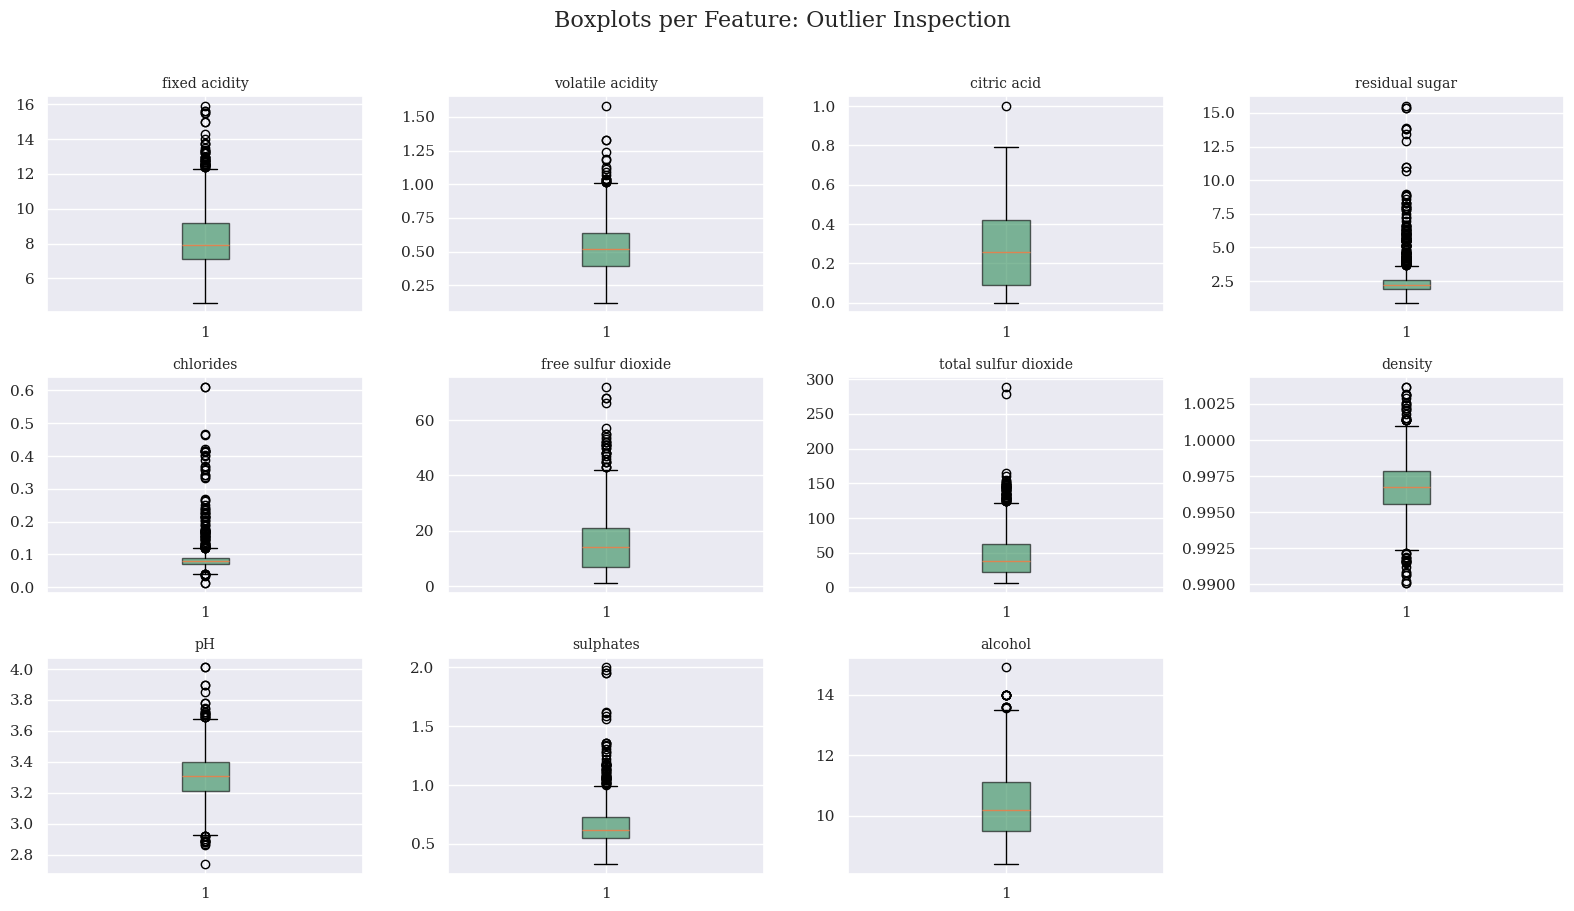

In [43]:
# 3. Outlier detection
feature_cols = [c for c in df.columns if (c != 'quality' and c != 'quality_label' and c != 'quality_label_name')]

# Convert columns to numeric if needed
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Boxplots for visual inspection
n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='seagreen', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots per Feature: Outlier Inspection', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [44]:
print("\nIQR Outlier Flag Summary (1.5×IQR rule)")
for col in feature_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col:30s}: {n_out:3d} flagged outliers")
print("\nRows are NOT dropped!")


IQR Outlier Flag Summary (1.5×IQR rule)
  fixed acidity                 :  49 flagged outliers
  volatile acidity              :  19 flagged outliers
  citric acid                   :   1 flagged outliers
  residual sugar                : 155 flagged outliers
  chlorides                     : 112 flagged outliers
  free sulfur dioxide           :  30 flagged outliers
  total sulfur dioxide          :  55 flagged outliers
  density                       :  45 flagged outliers
  pH                            :  35 flagged outliers
  sulphates                     :  59 flagged outliers
  alcohol                       :  13 flagged outliers

Rows are NOT dropped!


In [45]:
# 4. Feature Engineering
df['quality_label'] = (df['quality'] >= 7).astype(int)

print("\nquality_label Distribution")
print("\n...")

vc = df['quality_label'].value_counts().rename(index={1: 'Good (>=7)', 0: 'Not Good (<7)'})
print(vc)

print(f"\nGood wine rate: {df['quality_label'].mean():.1%}")


quality_label Distribution

...
quality_label
Not Good (<7)    1382
Good (>=7)        217
Name: count, dtype: int64

Good wine rate: 13.6%


In [46]:
#5. Train/Test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_all = df[feature_cols]  # all physicochemical features
y_reg = df['quality']  # regression target
y_clf = df['quality_label']  # classification target (binary)

X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X_all, y_reg, y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_sc  = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

print("\nTrain/Test Split")
print("...")
print(f"Training set : {X_train_sc.shape} | Good rate: {y_train_clf.mean():.1%}")
print(f"Test set     : {X_test_sc.shape}  | Good rate: {y_test_clf.mean():.1%}")
print("\nData Preparation complete!")


Train/Test Split
...
Training set : (1279, 11) | Good rate: 13.6%
Test set     : (320, 11)  | Good rate: 13.4%

Data Preparation complete!


#Exploratory Data Analysis (Han)
- Summary Stats (done above)
- Correlation heatmap
- Feature Importance (correlation)
- Histogram & bar chart: Quality Score Distribution
- Scatterplot: two high-impact features (alcohol & volatile acidity)
- Box plots: All features by Quality Label(good/not) & Quality Scores(3-8)


In [47]:
# build own sns palette
sns.color_palette('Set2',2)

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961)]

In [48]:
color = sns.color_palette('Set2',2)
sns.set_palette(color)
print(color)

[(0.4, 0.7607843137254902, 0.6470588235294118), (0.9882352941176471, 0.5529411764705883, 0.3843137254901961)]


In [49]:
# add new column with classification label
df['quality_label_name'] = df['quality_label'].map({0: 'Not Good (<7)', 1: 'Good (>=7)'})

In [50]:
# summary statistics (+1 columns)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  quality_label         1599 non-null   int64  
 13  quality_label_name    1599 non-null   object 
dtypes: float64(11), int64(2), object(1)
memory usage: 175.0+ KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,0.135710
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,0.342587
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,0.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,0.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1.000000


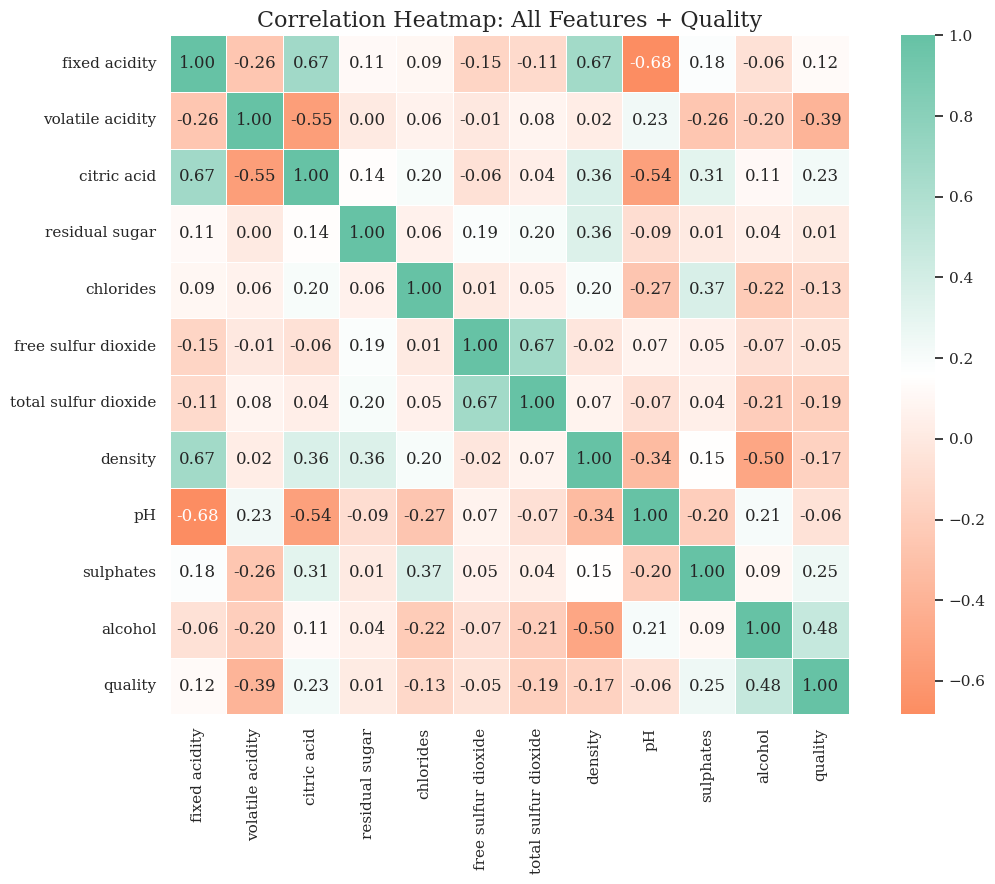

In [51]:
# Correlation heatmap
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list(
    'green_orange',
     #['coral', 'white', 'mediumseagreen']
    [(0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
     'white',(0.4, 0.7607843137254902, 0.6470588235294118) ]
)
plt.figure(figsize=(12, 9))
corr_matrix = df.drop(columns=['quality_label', 'quality_label_name']).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap=custom_cmap, #plt.cm.Blues or RdYlGn
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap: All Features + Quality', fontsize=16)
plt.tight_layout()
plt.show()

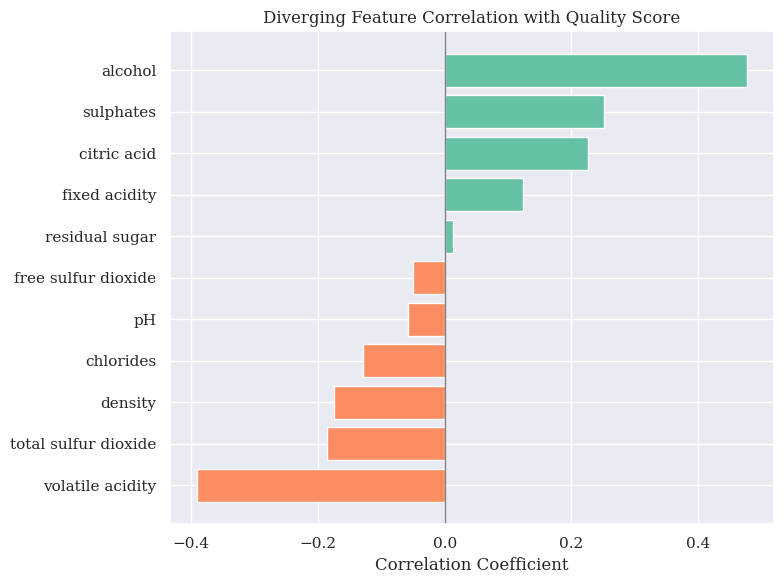

In [52]:
# get correlations with quality, drop non-numb(quality, quality_label and quality_label_name) themselves
quality_corr = df.select_dtypes(include='number').corr()['quality'].drop(['quality', 'quality_label']).sort_values()
# set color: positive = green, negative = orange
colors = [color[1] if v < 0 else color[0] for v in quality_corr.values]
plt.figure(figsize=(8, 6))
plt.barh(quality_corr.index, quality_corr.values, color=colors)
plt.axvline(x=0, color='gray', linewidth=1)  #centre line
plt.title('Diverging Feature Correlation with Quality Score')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

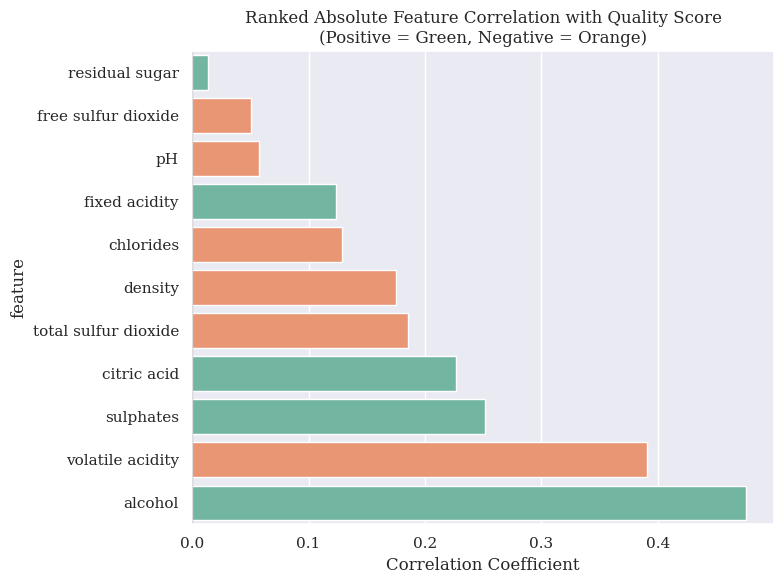

In [53]:
# feature importance, ranked high-low (absolute correlation with quality)
rank_df = (df.select_dtypes(include='number').corr()['quality'].drop(['quality', 'quality_label']).sort_values().reset_index())
rank_df.columns = ['feature', 'correlation']
rank_df['direction'] = rank_df['correlation'].apply(lambda x: 'negative' if x < 0 else 'positive')
rank_df['abs_correlation'] = rank_df['correlation'].abs()
rank_df = rank_df.sort_values('abs_correlation')
plt.figure(figsize=(8, 6))
sns.barplot(
    data=rank_df,
    x='abs_correlation',
    y='feature',
    hue='direction',
    palette={'positive': color[0], 'negative': color[1]},
    legend=False
)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Ranked Absolute Feature Correlation with Quality Score\n(Positive = Green, Negative = Orange)')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

#### Distribution of quality scores (histogram + bar chart)

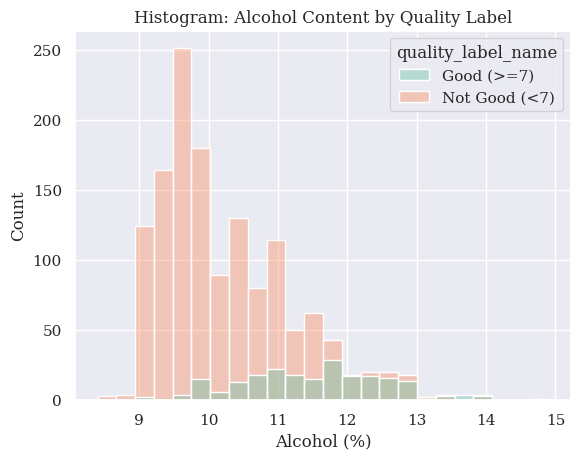

In [54]:
# 1. Histogram: alchol dist by quality label
sns.histplot(
    data=df,
    x='alcohol',
    hue='quality_label_name',
    hue_order=['Good (>=7)', 'Not Good (<7)'],
    alpha=0.4,
    palette={'Good (>=7)': color[0], 'Not Good (<7)': color[1]} #'hls' #ref:husl, paired, pastel, dark
)
plt.title('Histogram: Alcohol Content by Quality Label')
plt.xlabel('Alcohol (%)')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_1375/713337836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_1375/713337836.py:4: UserWarning: The palette list has more values (9) than needed (6), which may not be intended.
  sns.countplot(


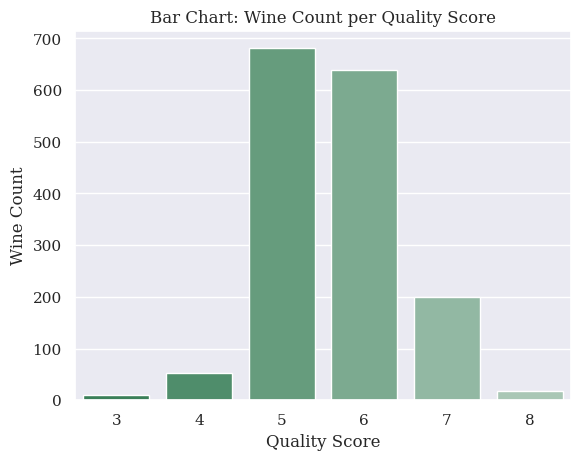

In [55]:
# 2. Bar chart: Wine Count per Quality Score
my_palette = sns.light_palette('seagreen', n_colors=9)
my_palette.reverse()
sns.countplot(
    data=df,
    x='quality',
    palette=my_palette)
plt.title('Bar Chart: Wine Count per Quality Score')
plt.xlabel('Quality Score')
plt.ylabel('Wine Count')
plt.show()

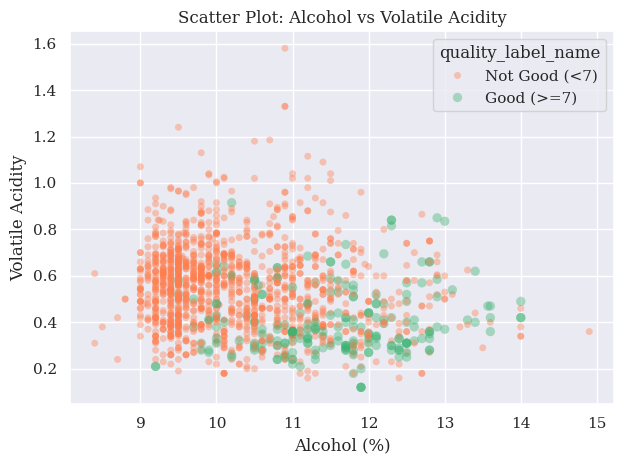

In [58]:
# 3. Scatterplot: alcohol vs volatile acidity, colored by quality label
sns.scatterplot(data=df, x='alcohol', y='volatile acidity', hue='quality_label_name',
                palette={'Good (>=7)': 'mediumseagreen', 'Not Good (<7)': 'coral'},
                #  {'Good (>=7)': color[0], 'Not Good (<7)': color[1]}, #Set2
                alpha=0.4, # self-note: for overlapping transparency
                edgecolor='None', # for no dot border color
                size='quality_label_name',
                sizes={'Good (>=7)': 45, 'Not Good (<7)': 25}
)
plt.title('Scatter Plot: Alcohol vs Volatile Acidity')
plt.xlabel('Alcohol (%)')
plt.ylabel('Volatile Acidity')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1375/363722531.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1375/363722531.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1375/363722531.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1375/363722531.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1375/363722531.py:6: FutureWarning: 

Passing `pa

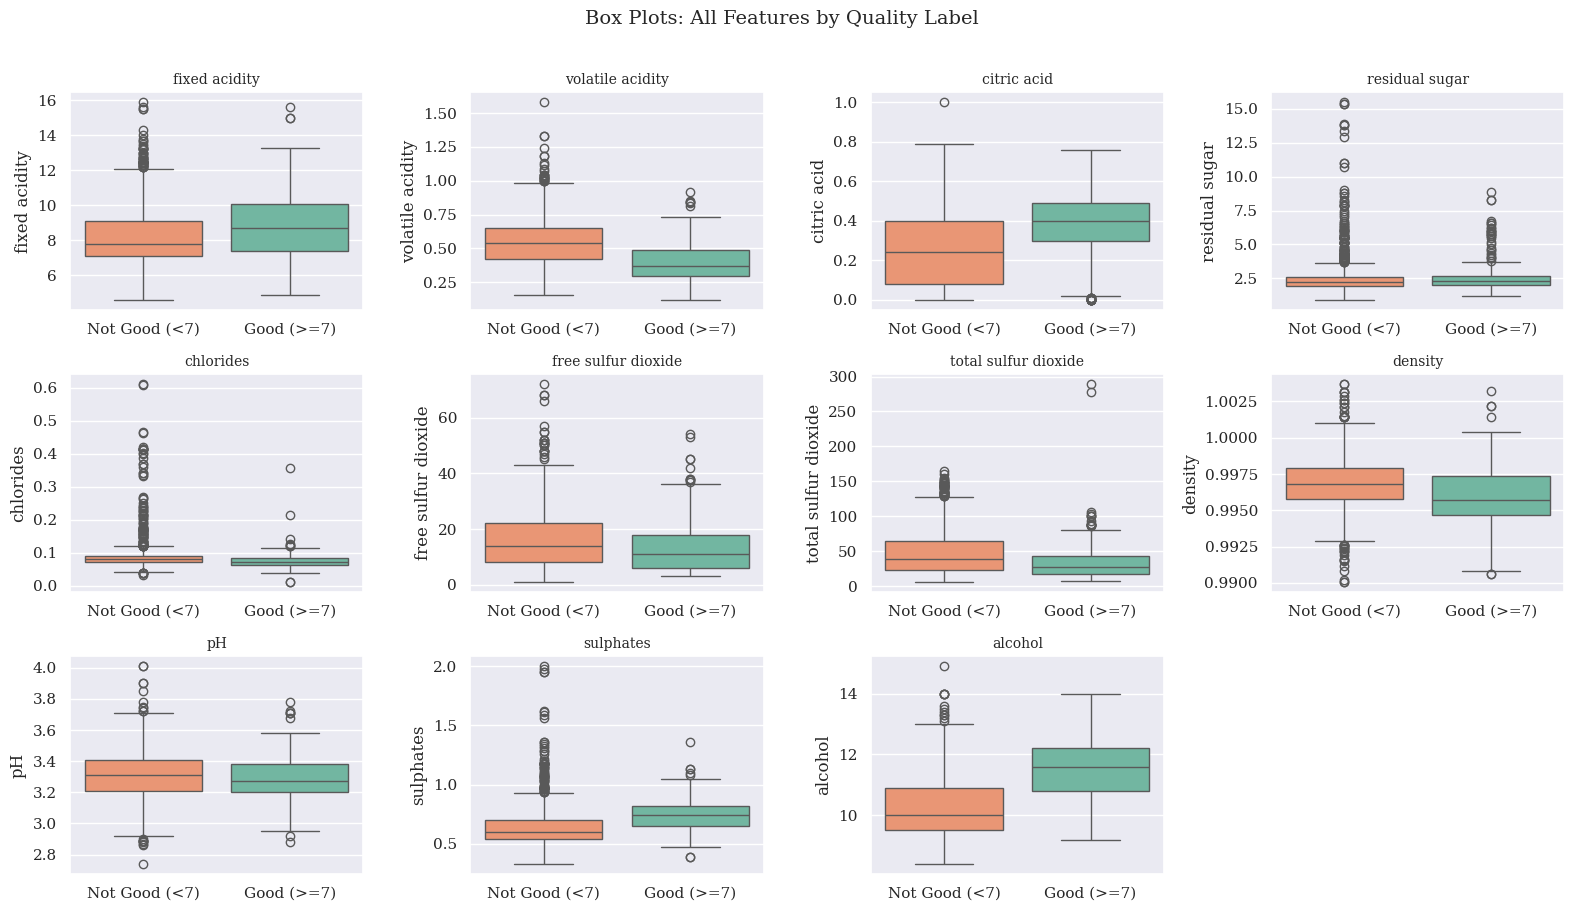

In [56]:
# 4. Box plots: all features by quality label, scores
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(
        data=df,
        x='quality_label_name',
        y=col,
        palette={'Good (>=7)': color[0], 'Not Good (<7)': color[1]},
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')  # cleaner, removes repeated x label

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots: All Features by Quality Label', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1375/2904092073.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1375/2904092073.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1375/2904092073.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1375/2904092073.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1375/2904092073.py:5: FutureWarning: 

Passin

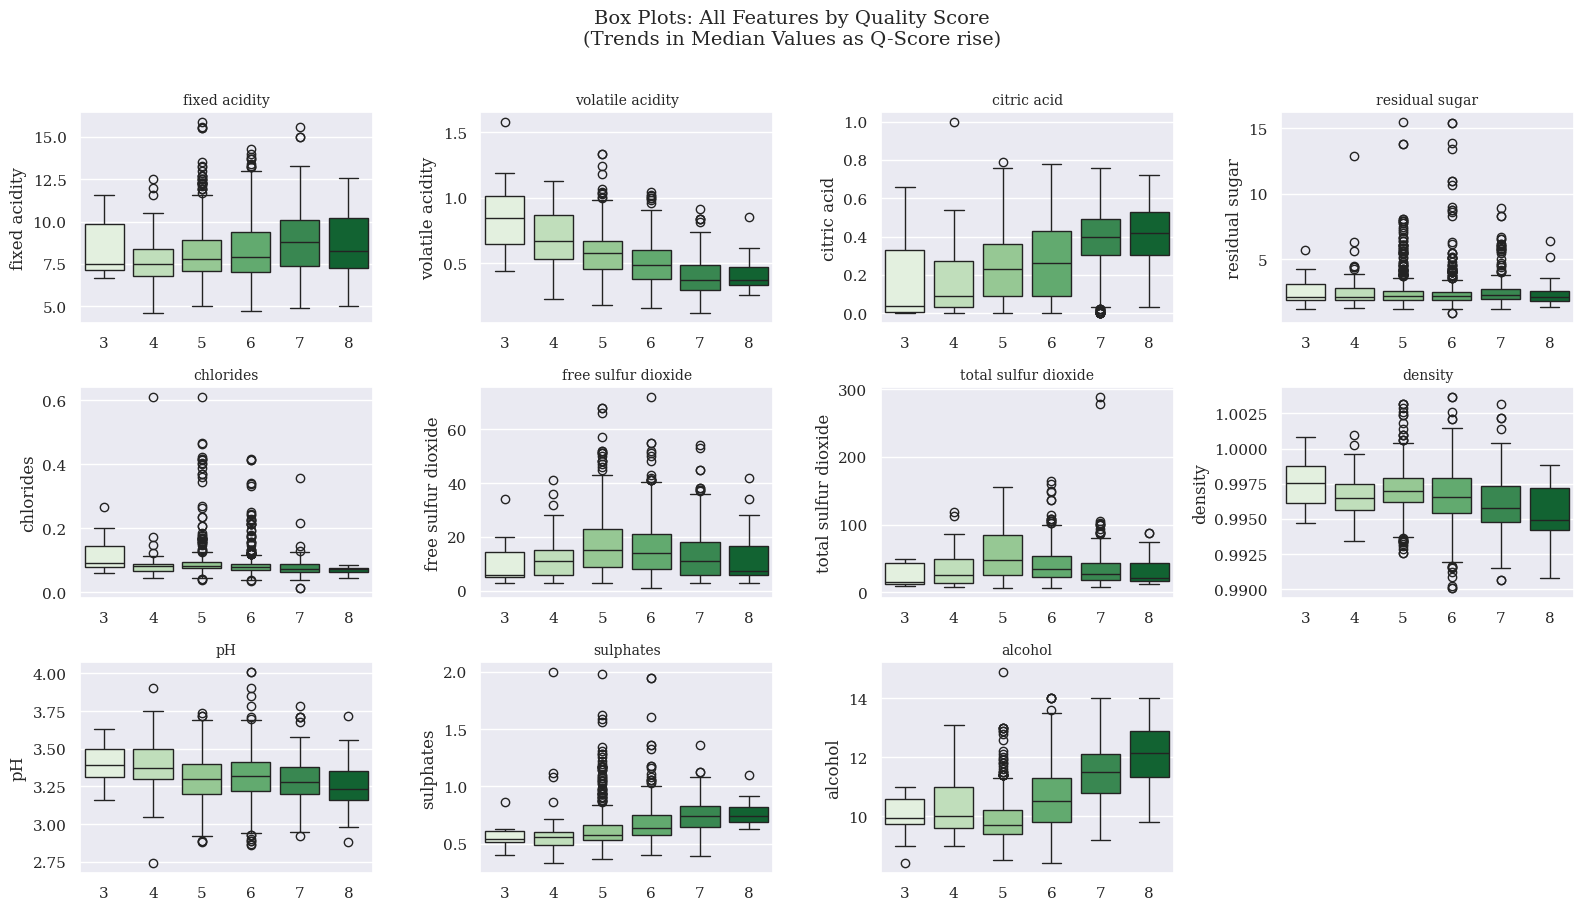

In [57]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(
        data=df,
        x='quality',
        y=col,
        palette='Greens',
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')  # cleaner, removes repeated x label

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots: All Features by Quality Score\n'+
'(Trends in Median Values as Q-Score rise)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Regression (Brian)
5 LR models

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Feature combo definitions

COMBOS = {
    1: {
        'name': 'All features ',
        'features': feature_cols,
    },
    2: {
        'name': 'Top 3 known predictors',
        'features': ['alcohol', 'volatile acidity', 'sulphates'],
    },
    3: {
        'name' : 'Flavor profile',
        'features': ['alcohol', 'volatile acidity', 'citric acid', 'density'],
    },
    4: {
        'name' : 'Top 5 by correlation',
        'features': ['alcohol', 'volatile acidity', 'sulphates',
                     'citric acid', 'total sulfur dioxide'],
    },
    5: {
        'name' : 'Low-collinearity set',
        'features': ['alcohol', 'volatile acidity', 'sulphates',
                     'pH', 'residual sugar'],
    },
}

# Run all 5 combos; same scaler fitted on X_train above
regression_results = []

for combo_id, combo in COMBOS.items():
    feats = combo['features']
    model = LinearRegression()
    model.fit(X_train_sc[feats], y_train_reg)

    y_pred_train = model.predict(X_train_sc[feats])
    y_pred_test  = model.predict(X_test_sc[feats])

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred_train))
    test_rmse  = np.sqrt(mean_squared_error(y_test_reg,  y_pred_test))
    train_r2   = r2_score(y_train_reg, y_pred_train)
    test_r2    = r2_score(y_test_reg,  y_pred_test)

    regression_results.append({
        'Combo': combo_id,
        'Name' : combo['name'],
        'Features Used': ', '.join(feats),
        'Num Features': len(feats),
        'Train RMSE' : round(train_rmse, 4),
        'Test RMSE': round(test_rmse,  4),
        'Train R2' : round(train_r2,   4),
        'Test R2': round(test_r2,    4),
    })

    print(f"\nCombo {combo_id}: {combo['name']}")
    print("...")
    print(f"Features : {feats}")
    print(f"Train RMSE : {train_rmse:.4f}  |  Test RMSE : {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}     |  Test R2   : {test_r2:.4f}")


Combo 1: All features 
...
Features : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Train RMSE : 0.6409  |  Test RMSE : 0.6687
Train R2: 0.3484     |  Test R2   : 0.3916

Combo 2: Top 3 known predictors
...
Features : ['alcohol', 'volatile acidity', 'sulphates']
Train RMSE : 0.6557  |  Test RMSE : 0.6694
Train R2: 0.3181     |  Test R2   : 0.3903

Combo 3: Flavor profile
...
Features : ['alcohol', 'volatile acidity', 'citric acid', 'density']
Train RMSE : 0.6610  |  Test RMSE : 0.6896
Train R2: 0.3069     |  Test R2   : 0.3530

Combo 4: Top 5 by correlation
...
Features : ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'total sulfur dioxide']
Train RMSE : 0.6497  |  Test RMSE : 0.6756
Train R2: 0.3305     |  Test R2   : 0.3790

Combo 5: Low-collinearity set
...
Features : ['alcohol', 'volatile acidity', 'sulphates', 'pH', 'residual sugar']
Train RMS

#Classification (Mahsa)
Decision Tree, KNN, Naive Bayes, Logistic Regression (bonus)

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Feature combinations for classification
classification_combos = {
    "All 11 features": feature_cols,
    "Top 5 by correlation": ['alcohol', 'volatile acidity', 'sulphates',
                             'citric acid', 'total sulfur dioxide']
}

print("Classification setup complete.")
print("Target variable: quality_label")
print("Feature combos:")
for name, feats in classification_combos.items():
    print(name, ":", feats)

Classification setup complete.
Target variable: quality_label
Feature combos:
All 11 features : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Top 5 by correlation : ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'total sulfur dioxide']


In [61]:
# Create scaled DataFrames for classification
X_train_scaled_df = pd.DataFrame(X_train, columns=feature_cols)
X_test_scaled_df = pd.DataFrame(X_test, columns=feature_cols)

y_train_class = y_train_clf
y_test_class = y_test_clf

print(X_train_scaled_df.shape)
print(X_test_scaled_df.shape)

(1279, 11)
(320, 11)


# **Decision Tree Classification**

In [62]:
# Decision Tree Classification
dt_results = []

for combo_name, features in classification_combos.items():
    X_train_combo = X_train_scaled_df[features]
    X_test_combo = X_test_scaled_df[features]

    for depth in [3, 5, 10, None]:
        for min_split in [2, 5, 10]:
            dt_model = DecisionTreeClassifier(
                criterion='entropy',
                max_depth=depth,
                min_samples_split=min_split,
                random_state=42
            )

            dt_model.fit(X_train_combo, y_train_class)
            y_pred = dt_model.predict(X_test_combo)

            dt_results.append({
                "Model": "Decision Tree",
                "Features": combo_name,
                "Max Depth": depth,
                "Min Samples Split": min_split,
                "Accuracy": accuracy_score(y_test_class, y_pred),
                "Precision": precision_score(y_test_class, y_pred, zero_division=0),
                "Recall": recall_score(y_test_class, y_pred, zero_division=0),
                "F1 Score": f1_score(y_test_class, y_pred, zero_division=0)
            })

dt_results_df = pd.DataFrame(dt_results)
dt_results_df.sort_values(by="F1 Score", ascending=False)

,Model,Features,Max Depth,Min Samples Split,Accuracy,Precision,Recall,F1 Score
10,Decision Tree,All 11 features,NaN,5,0.925000,0.731707,0.697674,0.714286
9,Decision Tree,All 11 features,NaN,2,0.925000,0.731707,0.697674,0.714286
11,Decision Tree,All 11 features,NaN,10,0.918750,0.717949,0.651163,0.682927
6,Decision Tree,All 11 features,10.0,2,0.912500,0.692308,0.627907,0.658537
7,Decision Tree,All 11 features,10.0,5,0.909375,0.694444,0.581395,0.632911
8,Decision Tree,All 11 features,10.0,10,0.906250,0.675676,0.581395,0.625000
4,Decision Tree,All 11 features,5.0,5,0.906250,0.709677,0.511628,0.594595
5,Decision Tree,All 11 features,5.0,10,0.906250,0.709677,0.511628,0.594595
3,Decision Tree,All 11 features,5.0,2,0.903125,0.687500,0.511628,0.586667
22,Decision Tree,Top 5 by correlation,NaN,5,0.884375,0.568182,0.581395,0.574713


# **KNN Classification**



In [63]:
# KNN Classification

knn_results = []

for combo_name, features in classification_combos.items():
    X_train_combo = X_train_scaled_df[features]
    X_test_combo = X_test_scaled_df[features]

    for k in [3, 5, 7, 11]:
        knn_model = KNeighborsClassifier(n_neighbors=k)

        knn_model.fit(X_train_combo, y_train_class)
        y_pred = knn_model.predict(X_test_combo)

        knn_results.append({
            "Model": "KNN",
            "Features": combo_name,
            "K": k,
            "Accuracy": accuracy_score(y_test_class, y_pred),
            "Precision": precision_score(y_test_class, y_pred, zero_division=0),
            "Recall": recall_score(y_test_class, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test_class, y_pred, zero_division=0)
        })

knn_results_df = pd.DataFrame(knn_results)
knn_results_df.sort_values(by="F1 Score", ascending=False)

,Model,Features,K,Accuracy,Precision,Recall,F1 Score
4,KNN,Top 5 by correlation,3,0.871875,0.531250,0.395349,0.453333
5,KNN,Top 5 by correlation,5,0.865625,0.500000,0.325581,0.394366
0,KNN,All 11 features,3,0.840625,0.388889,0.325581,0.354430
2,KNN,All 11 features,7,0.871875,0.550000,0.255814,0.349206
6,KNN,Top 5 by correlation,7,0.868750,0.526316,0.232558,0.322581
1,KNN,All 11 features,5,0.859375,0.454545,0.232558,0.307692
7,KNN,Top 5 by correlation,11,0.871875,0.600000,0.139535,0.226415
3,KNN,All 11 features,11,0.859375,0.400000,0.093023,0.150943


# **Naive Bayes Classification**

In [64]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes Classification

nb_results = []

for combo_name, features in classification_combos.items():
    X_train_combo = X_train_scaled_df[features]
    X_test_combo = X_test_scaled_df[features]

    nb_model = GaussianNB()

    nb_model.fit(X_train_combo, y_train_class)
    y_pred = nb_model.predict(X_test_combo)

    nb_results.append({
        "Model": "Naive Bayes",
        "Features": combo_name,
        "Accuracy": accuracy_score(y_test_class, y_pred),
        "Precision": precision_score(y_test_class, y_pred, zero_division=0),
        "Recall": recall_score(y_test_class, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test_class, y_pred, zero_division=0)
    })

nb_results_df = pd.DataFrame(nb_results)
nb_results_df.sort_values(by="F1 Score", ascending=False)

,Model,Features,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,All 11 features,0.865625,0.500000,0.720930,0.590476
1,Naive Bayes,Top 5 by correlation,0.884375,0.568182,0.581395,0.574713


# **Logistic Regression Classification**

In [65]:
# Logistic Regression Classification

lr_results = []

for combo_name, features in classification_combos.items():
    X_train_combo = X_train_scaled_df[features]
    X_test_combo = X_test_scaled_df[features]

    lr_model = LogisticRegression(max_iter=1000, random_state=42)

    lr_model.fit(X_train_combo, y_train_class)
    y_pred = lr_model.predict(X_test_combo)

    lr_results.append({
        "Model": "Logistic Regression",
        "Features": combo_name,
        "Accuracy": accuracy_score(y_test_class, y_pred),
        "Precision": precision_score(y_test_class, y_pred, zero_division=0),
        "Recall": recall_score(y_test_class, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test_class, y_pred, zero_division=0)
    })

lr_results_df = pd.DataFrame(lr_results)
lr_results_df.sort_values(by="F1 Score", ascending=False)

,Model,Features,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,All 11 features,0.89375,0.736842,0.325581,0.451613
1,Logistic Regression,Top 5 by correlation,0.89375,0.764706,0.302326,0.433333


# Summary Table + Best Model + Confusion Matrix

In [66]:
# Combine all results
all_results = pd.concat([
    dt_results_df[['Model','Features','Accuracy','Precision','Recall','F1 Score']],
    knn_results_df[['Model','Features','Accuracy','Precision','Recall','F1 Score']],
    nb_results_df[['Model','Features','Accuracy','Precision','Recall','F1 Score']],
    lr_results_df[['Model','Features','Accuracy','Precision','Recall','F1 Score']]
], ignore_index=True)

# Show top results
summary_table = all_results.sort_values(by='F1 Score', ascending=False)
print("Classification Model Comparison:")
display(summary_table)

# Best model = Decision Tree
best_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=None,
    min_samples_split=5,
    random_state=42
)

best_model.fit(X_train_scaled_df[feature_cols], y_train_class)
y_best_pred = best_model.predict(X_test_scaled_df[feature_cols])

cm = confusion_matrix(y_test_class, y_best_pred)

print("Confusion Matrix (Best Model: Decision Tree)")
print(cm)
print()
print(classification_report(y_test_class, y_best_pred))

Classification Model Comparison:


,Model,Features,Accuracy,Precision,Recall,F1 Score
9,Decision Tree,All 11 features,0.925000,0.731707,0.697674,0.714286
10,Decision Tree,All 11 features,0.925000,0.731707,0.697674,0.714286
11,Decision Tree,All 11 features,0.918750,0.717949,0.651163,0.682927
6,Decision Tree,All 11 features,0.912500,0.692308,0.627907,0.658537
7,Decision Tree,All 11 features,0.909375,0.694444,0.581395,0.632911
8,Decision Tree,All 11 features,0.906250,0.675676,0.581395,0.625000
4,Decision Tree,All 11 features,0.906250,0.709677,0.511628,0.594595
5,Decision Tree,All 11 features,0.906250,0.709677,0.511628,0.594595
32,Naive Bayes,All 11 features,0.865625,0.500000,0.720930,0.590476
3,Decision Tree,All 11 features,0.903125,0.687500,0.511628,0.586667


Confusion Matrix (Best Model: Decision Tree)
[[266  11]
 [ 13  30]]

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       277
           1       0.73      0.70      0.71        43

    accuracy                           0.93       320
   macro avg       0.84      0.83      0.84       320
weighted avg       0.92      0.93      0.92       320



# **Summary of Classification Results**

The classification task compared four models: Decision Tree, KNN, Naive Bayes and and Logistic Regression using two feature sets (all 11 features and top 5 correlated features).

The best performing model was the Decision Tree classifier using all 11 features with max_depth=None and min_samples_split=5. It achieved an Accuracy of 0.9250, Precision of 0.7317, Recall of 0.6977, and the highest F1 Score of 0.7143.
== 92.5% accuracy, 73.2% precision, 69.8% recall, and 71.4% F1 score.

Naive Bayes performed moderately well, reaching an F1 score of 59.0%, while KNN had the weakest performance overall.

The KNN model performed worse than Decision Tree. Its best result came from using the Top 5 correlated features with k=3, producing an Accuracy of 0.8719 and F1 Score of 0.4533.

Logistic Regression showed similar performance to KNN but lower than Decision Tree. Its best model used all 11 features and achieved an Accuracy of 0.8938 with an F1 Score of 0.4516.

Overall, the Decision Tree model was the strongest classifier because it provided the best balance between precision and recall, resulting in the highest F1 Score.

#Conclusion | Summary: (View Report)